# Fine-tune Qwen2.5 1.5B Instruct bằng QLoRA cho tóm tắt tiếng Việt

Notebook này dùng toàn bộ tập train và toàn bộ tập valid:

- Train: `/kaggle/input/datasets/flowboat/nlp-code/train-00000-of-00001.parquet`
- Valid: `/kaggle/input/datasets/flowboat/nlp-code/valid-00000-of-00001.parquet`
- Base model: `/kaggle/input/models/qwen-lm/qwen2.5/transformers/1.5b-instruct/1`

Notebook gồm:

1. Cài thư viện
2. Load dữ liệu parquet
3. Tiền xử lý và thống kê dữ liệu chi tiết
4. Load Qwen2.5 1.5B Instruct ở 4-bit
5. Tokenize theo format chat
6. Fine-tune bằng QLoRA
7. Evaluate loss/perplexity trên toàn bộ valid
8. Generate tóm tắt cho toàn bộ valid và tính ROUGE
9. Lưu LoRA adapter, báo cáo tiền xử lý, kết quả dự đoán

In [1]:
!pip install -q -U transformers accelerate peft bitsandbytes datasets evaluate rouge_score sacrebleu sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 98.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 95.5 MB/s eta 0:00:00


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import math
import gc
import random
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
import evaluate

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
Tesla T4


## 1. Cấu hình đường dẫn và hyperparameters

Bạn có thể giảm `MAX_LENGTH` xuống `2048` nếu gặp thiếu VRAM. Với Kaggle T4, cấu hình mặc định dưới đây thường hợp lý cho QLoRA.

In [3]:
MODEL_PATH = "/kaggle/input/models/qwen-lm/qwen2.5/transformers/1.5b-instruct/1"
TRAIN_PATH = "/kaggle/input/datasets/flowboat/nlp-code/train-00000-of-00001.parquet"
VALID_PATH = "/kaggle/input/datasets/flowboat/nlp-code/valid-00000-of-00001.parquet"

OUTPUT_DIR = "/kaggle/working/qwen2_5_1_5b_qlora_summarization"
ADAPTER_DIR = f"{OUTPUT_DIR}/lora_adapter"
PREPROCESS_REPORT_PATH = f"{OUTPUT_DIR}/preprocess_report.csv"
VALID_PRED_PATH = f"{OUTPUT_DIR}/valid_predictions_full.csv"
ROUGE_REPORT_PATH = f"{OUTPUT_DIR}/rouge_full_valid.csv"
BLEU_REPORT_PATH = f"{OUTPUT_DIR}/bleu_full_valid.csv"
EVAL_SUMMARY_PATH = f"{OUTPUT_DIR}/eval_summary_rouge_bleu.csv"

os.makedirs(OUTPUT_DIR, exist_ok=True)

ARTICLE_COL = "article"
SUMMARY_COL = "summary"

MAX_LENGTH = 3072
MAX_NEW_TOKENS = 220

NUM_EPOCHS = 1
BATCH_SIZE = 1
GRAD_ACCUM = 8
LEARNING_RATE = 2e-4
WARMUP_STEPS = 50

EVAL_STEPS = 200
SAVE_STEPS = 200
LOGGING_STEPS = 20

print("Output dir:", OUTPUT_DIR)

Output dir: /kaggle/working/qwen2_5_1_5b_qlora_summarization


## 2. Load dữ liệu parquet

In [4]:
train_raw = pd.read_parquet(TRAIN_PATH)
valid_raw = pd.read_parquet(VALID_PATH)

print("Train raw shape:", train_raw.shape)
print("Valid raw shape:", valid_raw.shape)
print("Train columns:", train_raw.columns.tolist())
print("Valid columns:", valid_raw.columns.tolist())

display(train_raw.head(3))
display(valid_raw.head(3))

Train raw shape: (10775, 2)
Valid raw shape: (1349, 2)
Train columns: ['article', 'summary']
Valid columns: ['article', 'summary']


,article,summary
0,Gần 20 sự kiện được tổ chức trên toàn thành ph...,Hà Nội tổ chức gần 20 sự kiện từ 19/4 đến 10/5...
1,"Được thành lập năm 1897 tại Đức, Kempinski Hot...",Kempinski Hotels là một thương hiệu nổi tiếng ...
2,"Ngoài di chuyển đến Tuần Châu bằng đường bộ, m...",Bài viết giới thiệu các hoạt động vui chơi giả...


,article,summary
0,Giải thưởng công bố gần đây bởi World Travel A...,InterContinental Phu Quoc Long Beach Resort đã...
1,Theo bảng xếp hạng 20 quốc gia tốt nhất thế gi...,Việt Nam đã xếp hạng 15 trên bảng xếp hạng 20 ...
2,"Ngày hội Văn hóa, Thể thao và Du lịch các dân ...","Ngày hội Văn hóa, Thể thao và Du lịch các dân ..."


## 3. Tiền xử lý dữ liệu

Các bước thực hiện:

- Chỉ giữ 2 cột `article`, `summary`
- Ép kiểu chuỗi
- Strip khoảng trắng đầu/cuối
- Chuẩn hóa khoảng trắng lặp
- Loại dòng null hoặc rỗng
- Loại duplicate chính xác theo cặp `article` + `summary`
- Thống kê độ dài theo ký tự, từ, token
- Kiểm tra giao giữa train và valid theo nội dung `article`

In [5]:
def basic_clean_text(x):
    if pd.isna(x):
        return None
    x = str(x)
    x = " ".join(x.split())
    return x.strip()


def preprocess_dataframe(df, name):
    report = {}
    report["split"] = name
    report["rows_raw"] = len(df)
    report["columns"] = ", ".join(df.columns.astype(str).tolist())

    missing_cols = [c for c in [ARTICLE_COL, SUMMARY_COL] if c not in df.columns]
    if missing_cols:
        raise ValueError(f"{name} thiếu cột: {missing_cols}")

    out = df[[ARTICLE_COL, SUMMARY_COL]].copy()

    report["null_article_raw"] = int(out[ARTICLE_COL].isna().sum())
    report["null_summary_raw"] = int(out[SUMMARY_COL].isna().sum())

    out[ARTICLE_COL] = out[ARTICLE_COL].map(basic_clean_text)
    out[SUMMARY_COL] = out[SUMMARY_COL].map(basic_clean_text)

    before_dropna = len(out)
    out = out.dropna(subset=[ARTICLE_COL, SUMMARY_COL]).copy()
    report["rows_after_dropna"] = len(out)
    report["rows_removed_null"] = before_dropna - len(out)

    empty_mask = (out[ARTICLE_COL].str.len() == 0) | (out[SUMMARY_COL].str.len() == 0)
    report["empty_rows"] = int(empty_mask.sum())
    out = out.loc[~empty_mask].copy()

    duplicated_pair = int(out.duplicated(subset=[ARTICLE_COL, SUMMARY_COL]).sum())
    duplicated_article = int(out.duplicated(subset=[ARTICLE_COL]).sum())
    duplicated_summary = int(out.duplicated(subset=[SUMMARY_COL]).sum())
    report["duplicate_article_summary_pairs"] = duplicated_pair
    report["duplicate_articles"] = duplicated_article
    report["duplicate_summaries"] = duplicated_summary

    out = out.drop_duplicates(subset=[ARTICLE_COL, SUMMARY_COL]).reset_index(drop=True)
    report["rows_after_dedup_pair"] = len(out)

    out["article_char_len"] = out[ARTICLE_COL].str.len()
    out["summary_char_len"] = out[SUMMARY_COL].str.len()
    out["article_word_len"] = out[ARTICLE_COL].str.split().str.len()
    out["summary_word_len"] = out[SUMMARY_COL].str.split().str.len()
    out["compression_ratio_word"] = out["summary_word_len"] / out["article_word_len"].replace(0, np.nan)

    return out, report

train_df, train_report = preprocess_dataframe(train_raw, "train")
valid_df, valid_report = preprocess_dataframe(valid_raw, "valid")

# Kiểm tra leakage đơn giản theo article giống hệt nhau
train_articles = set(train_df[ARTICLE_COL].tolist())
valid_articles = set(valid_df[ARTICLE_COL].tolist())
overlap_articles = train_articles.intersection(valid_articles)
train_report["article_overlap_with_other_split"] = len(overlap_articles)
valid_report["article_overlap_with_other_split"] = len(overlap_articles)

print("Train cleaned shape:", train_df.shape)
print("Valid cleaned shape:", valid_df.shape)
print("Article overlap train-valid:", len(overlap_articles))

preprocess_basic_report = pd.DataFrame([train_report, valid_report])
display(preprocess_basic_report)

Train cleaned shape: (10775, 7)
Valid cleaned shape: (1349, 7)
Article overlap train-valid: 0


,split,rows_raw,columns,null_article_raw,null_summary_raw,rows_after_dropna,rows_removed_null,empty_rows,duplicate_article_summary_pairs,duplicate_articles,duplicate_summaries,rows_after_dedup_pair,article_overlap_with_other_split
0,train,10775,"article, summary",0,0,10775,0,0,0,0,0,10775,0
1,valid,1349,"article, summary",0,0,1349,0,0,0,0,0,1349,0


## 4. Thống kê độ dài theo ký tự và số từ

In [6]:
def describe_lengths(df, split_name):
    cols = [
        "article_char_len", "summary_char_len",
        "article_word_len", "summary_word_len",
        "compression_ratio_word",
    ]
    desc = df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).T
    desc.insert(0, "split", split_name)
    return desc.reset_index().rename(columns={"index": "metric"})

length_report = pd.concat([
    describe_lengths(train_df, "train"),
    describe_lengths(valid_df, "valid"),
], ignore_index=True)

display(length_report)

,metric,split,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
0,article_char_len,train,10775.0,2128.273503,464.816366,1286.000000,1394.000000,1484.000000,1768.000000,2061.000000,2402.500000,2854.600000,3042.000000,3232.000000,3580.000000
1,summary_char_len,train,10775.0,469.345800,99.289555,222.000000,279.000000,322.000000,395.000000,458.000000,540.000000,611.000000,645.000000,694.000000,792.000000
2,article_word_len,train,10775.0,458.153225,99.542925,300.000000,303.000000,319.000000,381.000000,444.000000,515.000000,615.000000,657.000000,691.000000,700.000000
3,summary_word_len,train,10775.0,102.576984,21.844511,50.000000,61.000000,70.000000,86.000000,100.000000,118.000000,134.000000,142.000000,149.000000,174.000000
4,compression_ratio_word,train,10775.0,0.231586,0.060189,0.080960,0.120357,0.142637,0.186877,0.225653,0.270270,0.312428,0.340265,0.391145,0.485050
5,article_char_len,valid,1349.0,2166.077094,474.897409,1319.000000,1397.440000,1503.000000,1804.000000,2085.000000,2462.000000,2904.200000,3059.000000,3252.080000,3434.000000
6,summary_char_len,valid,1349.0,467.303188,99.544254,242.000000,286.960000,327.400000,387.000000,459.000000,536.000000,611.200000,643.600000,695.080000,785.000000
7,article_word_len,valid,1349.0,466.449963,102.597511,300.000000,305.480000,320.000000,388.000000,450.000000,533.000000,628.400000,663.600000,693.000000,700.000000
8,summary_word_len,valid,1349.0,102.068199,21.947633,54.000000,60.480000,69.000000,85.000000,100.000000,118.000000,134.000000,141.000000,148.000000,164.000000
9,compression_ratio_word,valid,1349.0,0.226700,0.059884,0.092537,0.114543,0.137098,0.183077,0.221918,0.263427,0.306204,0.331311,0.384947,0.486667


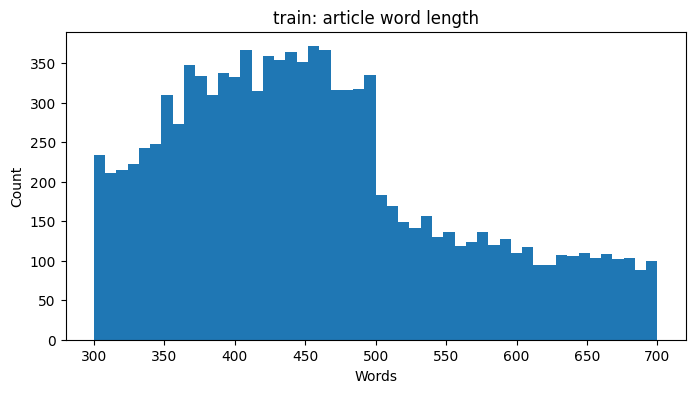

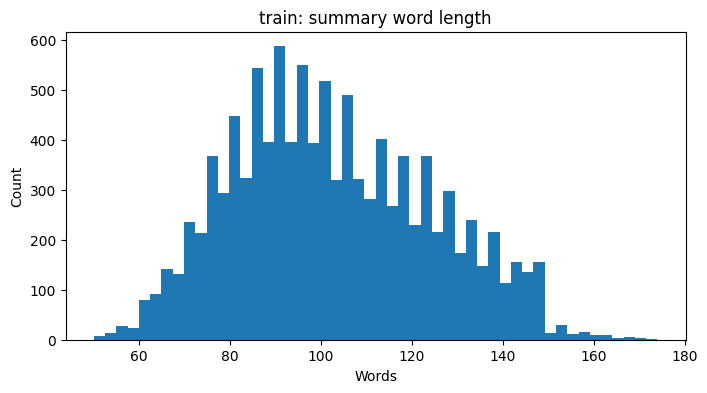

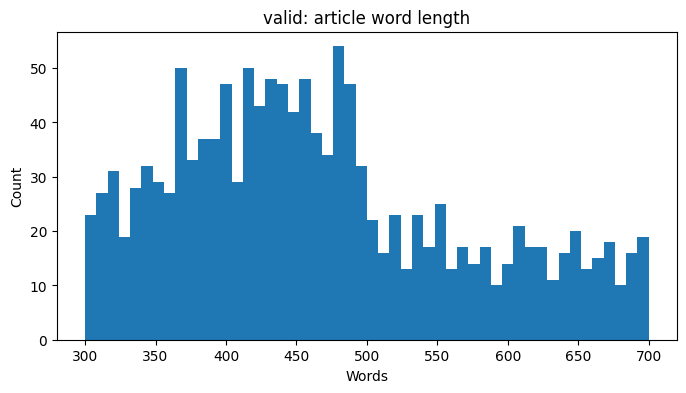

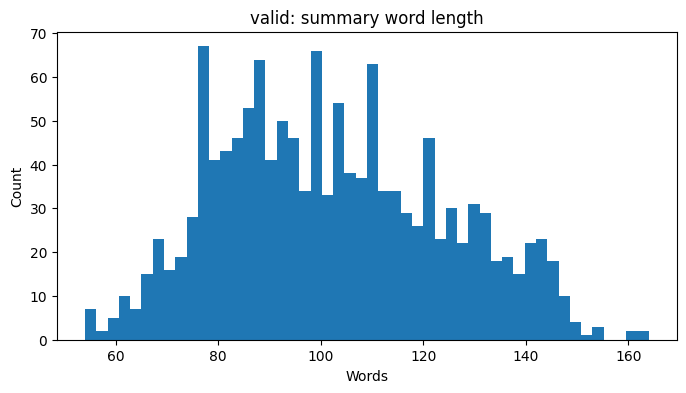

In [7]:
import matplotlib.pyplot as plt

for split_name, df in [("train", train_df), ("valid", valid_df)]:
    plt.figure(figsize=(8, 4))
    plt.hist(df["article_word_len"], bins=50)
    plt.title(f"{split_name}: article word length")
    plt.xlabel("Words")
    plt.ylabel("Count")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(df["summary_word_len"], bins=50)
    plt.title(f"{split_name}: summary word length")
    plt.xlabel("Words")
    plt.ylabel("Count")
    plt.show()

## 5. Load tokenizer và thống kê token

Phần này đo độ dài token của `article`, `summary`, prompt và full training sample. Đây là số liệu quan trọng vì fine-tune causal LM bị giới hạn bởi `MAX_LENGTH`.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_PATH,
    trust_remote_code=True,
    use_fast=True,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = "right"

print("pad_token:", tokenizer.pad_token)
print("eos_token:", tokenizer.eos_token)
print("chat_template exists:", tokenizer.chat_template is not None)

pad_token: <|endoftext|>
eos_token: <|im_end|>
chat_template exists: True


In [9]:
def build_messages(article, summary=None):
    system_msg = "Bạn là trợ lý AI chuyên tóm tắt văn bản tiếng Việt một cách ngắn gọn, đầy đủ ý chính và không thêm thông tin ngoài văn bản."
    user_msg = f"""Hãy tóm tắt văn bản sau bằng tiếng Việt.

Yêu cầu:
- Tóm tắt ngắn gọn
- Giữ các ý chính quan trọng
- Không bịa thêm thông tin
- Viết thành một đoạn văn mạch lạc

Văn bản:
{article}

Tóm tắt:"""
    messages = [
        {"role": "system", "content": system_msg},
        {"role": "user", "content": user_msg},
    ]
    if summary is not None:
        messages.append({"role": "assistant", "content": summary})
    return messages


def build_prompt(article):
    return tokenizer.apply_chat_template(
        build_messages(article, summary=None),
        tokenize=False,
        add_generation_prompt=True,
    )


def build_full_text(article, summary):
    text = tokenizer.apply_chat_template(
        build_messages(article, summary=summary),
        tokenize=False,
        add_generation_prompt=False,
    )
    if tokenizer.eos_token and not text.endswith(tokenizer.eos_token):
        text += tokenizer.eos_token
    return text

# Test format
print(build_prompt(train_df.loc[0, ARTICLE_COL])[:1000])

<|im_start|>system
Bạn là trợ lý AI chuyên tóm tắt văn bản tiếng Việt một cách ngắn gọn, đầy đủ ý chính và không thêm thông tin ngoài văn bản.<|im_end|>
<|im_start|>user
Hãy tóm tắt văn bản sau bằng tiếng Việt.

Yêu cầu:
- Tóm tắt ngắn gọn
- Giữ các ý chính quan trọng
- Không bịa thêm thông tin
- Viết thành một đoạn văn mạch lạc

Văn bản:
Gần 20 sự kiện được tổ chức trên toàn thành phố, kéo dài từ 19/4 đến 10/5. Theo Sở Du lịch Hà Nội, ngoài thu hút du khách, loạt sự kiện cũng là các gợi ý dành cho người dân thủ đô không đi chơi xa và muốn tham gia các hoạt động trong ngày. Một số hoạt động tiêu biểu gồm Lễ hội Du lịch Hà Nội 2024 với chủ đề 'Thăng Long - Hà Nội, Thủ đô quyến rũ'; Triển lãm Ngô Quyền - Anh hùng dân tộc kiệt xuất và Thăng Long hội tụ; Việt Nam - những chiến thắng làm thay đổi dòng chảy lịch sử thế giới hay Tái hiện lễ hội Cầu mưa dân tộc Lô Lô, tỉnh Cao Bằng, Lễ hội Tình yêu năm 2024. Bên cạnh đó, nhân dịp kỷ niệm ngày Giải phóng miền Nam, thống nhất đất nước 30/4 - Quố

In [10]:
def token_len(text):
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

# Token stats có thể tốn thời gian một chút nhưng hữu ích.
# Với ~10k mẫu vẫn ổn trên Kaggle.
def add_token_stats(df, split_name):
    article_token_lens = []
    summary_token_lens = []
    prompt_token_lens = []
    full_token_lens = []

    for article, summary in tqdm(zip(df[ARTICLE_COL], df[SUMMARY_COL]), total=len(df), desc=f"Token stats {split_name}"):
        article_token_lens.append(token_len(article))
        summary_token_lens.append(token_len(summary))
        prompt_token_lens.append(token_len(build_prompt(article)))
        full_token_lens.append(token_len(build_full_text(article, summary)))

    df = df.copy()
    df["article_token_len"] = article_token_lens
    df["summary_token_len"] = summary_token_lens
    df["prompt_token_len"] = prompt_token_lens
    df["full_token_len"] = full_token_lens
    df["will_truncate_full"] = df["full_token_len"] > MAX_LENGTH
    return df

train_df = add_token_stats(train_df, "train")
valid_df = add_token_stats(valid_df, "valid")

print("Train samples > MAX_LENGTH:", int(train_df["will_truncate_full"].sum()), "/", len(train_df))
print("Valid samples > MAX_LENGTH:", int(valid_df["will_truncate_full"].sum()), "/", len(valid_df))

Token stats train:   0%|          | 0/10775 [00:00<?, ?it/s]

Token stats valid:   0%|          | 0/1349 [00:00<?, ?it/s]

Train samples > MAX_LENGTH: 0 / 10775
Valid samples > MAX_LENGTH: 0 / 1349


In [11]:
def describe_token_lengths(df, split_name):
    cols = ["article_token_len", "summary_token_len", "prompt_token_len", "full_token_len"]
    desc = df[cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).T
    desc.insert(0, "split", split_name)
    desc["num_over_max_length"] = [int((df[c] > MAX_LENGTH).sum()) for c in cols]
    desc["pct_over_max_length"] = [float((df[c] > MAX_LENGTH).mean()) for c in cols]
    return desc.reset_index().rename(columns={"index": "metric"})

token_report = pd.concat([
    describe_token_lengths(train_df, "train"),
    describe_token_lengths(valid_df, "valid"),
], ignore_index=True)

display(token_report)

preprocess_report = pd.concat([
    preprocess_basic_report.assign(report_type="basic"),
], ignore_index=True)

length_report.to_csv(f"{OUTPUT_DIR}/length_report.csv", index=False)
token_report.to_csv(f"{OUTPUT_DIR}/token_report.csv", index=False)
preprocess_basic_report.to_csv(PREPROCESS_REPORT_PATH, index=False)

print("Saved basic preprocess report to:", PREPROCESS_REPORT_PATH)
print("Saved length report to:", f"{OUTPUT_DIR}/length_report.csv")
print("Saved token report to:", f"{OUTPUT_DIR}/token_report.csv")

,metric,split,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max,num_over_max_length,pct_over_max_length
0,article_token_len,train,10775.0,633.164548,139.939727,366.0,403.00,439.0,528.0,611.0,717.0,842.0,903.0,990.00,1137.0,0,0.0
1,summary_token_len,train,10775.0,137.722691,29.674797,59.0,82.00,95.0,116.0,135.0,158.0,179.0,191.0,210.00,244.0,0,0.0
2,prompt_token_len,train,10775.0,737.558144,139.892594,471.0,508.00,544.0,632.0,715.0,822.0,946.6,1007.0,1094.00,1241.0,0,0.0
3,full_token_len,train,10775.0,878.280835,149.098321,545.0,622.74,667.0,768.0,859.0,966.0,1096.0,1161.3,1264.00,1445.0,0,0.0
4,article_token_len,valid,1349.0,645.593032,141.696220,369.0,408.48,443.8,540.0,625.0,735.0,855.0,914.4,1000.04,1090.0,0,0.0
5,summary_token_len,valid,1349.0,137.487027,29.542971,60.0,84.48,95.0,115.0,134.0,157.0,178.2,189.0,209.00,265.0,0,0.0
6,prompt_token_len,valid,1349.0,749.963677,141.642409,473.0,513.00,548.4,645.0,729.0,839.0,959.0,1019.4,1104.52,1195.0,0,0.0
7,full_token_len,valid,1349.0,890.450704,150.082801,583.0,621.48,675.4,780.0,872.0,987.0,1104.2,1171.2,1268.08,1369.0,0,0.0


Saved basic preprocess report to: /kaggle/working/qwen2_5_1_5b_qlora_summarization/preprocess_report.csv
Saved length report to: /kaggle/working/qwen2_5_1_5b_qlora_summarization/length_report.csv
Saved token report to: /kaggle/working/qwen2_5_1_5b_qlora_summarization/token_report.csv


## 6. Load model 4-bit và cấu hình QLoRA

In [12]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

model.config.use_cache = False
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 7. Tokenize cho supervised fine-tuning

Ta mask phần prompt bằng `-100`, chỉ tính loss trên phần câu trả lời `summary`.

Lưu ý: nếu `full_text` dài hơn `MAX_LENGTH`, phần cuối có thể bị cắt. Báo cáo ở trên cho biết bao nhiêu mẫu bị cắt.

In [13]:
def tokenize_example(example):
    article = example[ARTICLE_COL]
    summary = example[SUMMARY_COL]

    prompt_text = build_prompt(article)
    full_text = build_full_text(article, summary)

    prompt_ids = tokenizer(
        prompt_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )["input_ids"]

    full = tokenizer(
        full_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    input_ids = full["input_ids"]
    attention_mask = full["attention_mask"]

    labels = input_ids.copy()
    prompt_len = min(len(prompt_ids), len(labels))
    labels[:prompt_len] = [-100] * prompt_len

    # Nếu vì truncation mà toàn bộ answer bị cắt, vẫn tránh sample không có label hữu ích.
    if all(x == -100 for x in labels):
        labels[-1] = input_ids[-1]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "length": len(input_ids),
    }

train_dataset = Dataset.from_pandas(train_df[[ARTICLE_COL, SUMMARY_COL]], preserve_index=False)
valid_dataset = Dataset.from_pandas(valid_df[[ARTICLE_COL, SUMMARY_COL]], preserve_index=False)

tokenized_train = train_dataset.map(
    tokenize_example,
    remove_columns=train_dataset.column_names,
    desc="Tokenizing train",
)

tokenized_valid = valid_dataset.map(
    tokenize_example,
    remove_columns=valid_dataset.column_names,
    desc="Tokenizing valid",
)

print(tokenized_train)
print(tokenized_valid)

Tokenizing train:   0%|          | 0/10775 [00:00<?, ? examples/s]

Tokenizing valid:   0%|          | 0/1349 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'length'],
    num_rows: 10775
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'length'],
    num_rows: 1349
})


In [14]:
def tokenized_length_report(ds, split_name):
    lengths = np.array(ds["length"])
    return pd.DataFrame([{
        "split": split_name,
        "num_samples": len(lengths),
        "min": int(lengths.min()),
        "p01": float(np.percentile(lengths, 1)),
        "p05": float(np.percentile(lengths, 5)),
        "p25": float(np.percentile(lengths, 25)),
        "p50": float(np.percentile(lengths, 50)),
        "p75": float(np.percentile(lengths, 75)),
        "p90": float(np.percentile(lengths, 90)),
        "p95": float(np.percentile(lengths, 95)),
        "p99": float(np.percentile(lengths, 99)),
        "max": int(lengths.max()),
        "mean": float(lengths.mean()),
        "num_equal_max_length": int((lengths == MAX_LENGTH).sum()),
        "pct_equal_max_length": float((lengths == MAX_LENGTH).mean()),
    }])

tok_ds_report = pd.concat([
    tokenized_length_report(tokenized_train, "train"),
    tokenized_length_report(tokenized_valid, "valid"),
], ignore_index=True)

display(tok_ds_report)
tok_ds_report.to_csv(f"{OUTPUT_DIR}/tokenized_dataset_length_report.csv", index=False)

,split,num_samples,min,p01,p05,p25,p50,p75,p90,p95,p99,max,mean,num_equal_max_length,pct_equal_max_length
0,train,10775,545,622.74,667.0,768.0,859.0,966.0,1096.0,1161.3,1264.00,1445,878.280835,0,0.0
1,valid,1349,583,621.48,675.4,780.0,872.0,987.0,1104.2,1171.2,1268.08,1369,890.450704,0,0.0


## 8. Train QLoRA trên toàn bộ tập train

Cell này dùng đúng API `processing_class=tokenizer` như bạn đã sửa thành công.

In [15]:
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LEARNING_RATE,
    warmup_steps=WARMUP_STEPS,
    lr_scheduler_type="cosine",
    logging_steps=LOGGING_STEPS,
    eval_strategy="steps",
    eval_steps=EVAL_STEPS,
    save_strategy="steps",
    save_steps=SAVE_STEPS,
    save_total_limit=2,
    fp16=True,
    bf16=False,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    max_grad_norm=0.3,
    report_to="none",
    remove_unused_columns=False,
    load_best_model_at_end=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_valid,
    data_collator=data_collator,
    processing_class=tokenizer,
)

trainer.train()

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss
200,0.569652,0.568314
400,0.553215,0.548508
600,0.539068,0.537066
800,0.521813,0.527870
1000,0.515741,0.519899
1200,0.503355,0.516298
1347,0.456896,0.515711


TrainOutput(global_step=1347, training_loss=0.5329412495373087, metrics={'train_runtime': 21076.5446, 'train_samples_per_second': 0.511, 'train_steps_per_second': 0.064, 'total_flos': 7.545070670668186e+16, 'train_loss': 0.5329412495373087, 'epoch': 1.0})

## 9. Lưu LoRA adapter

In [16]:
trainer.save_model(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print("Saved LoRA adapter to:", ADAPTER_DIR)

Saved LoRA adapter to: /kaggle/working/qwen2_5_1_5b_qlora_summarization/lora_adapter


## 10. Evaluate loss/perplexity trên toàn bộ valid

Đây là đánh giá teacher-forcing trên toàn bộ tập valid đã tokenize.

In [17]:
eval_metrics = trainer.evaluate(eval_dataset=tokenized_valid)
print(eval_metrics)

if "eval_loss" in eval_metrics:
    ppl = math.exp(eval_metrics["eval_loss"]) if eval_metrics["eval_loss"] < 20 else float("inf")
    print("Validation perplexity:", ppl)

pd.DataFrame([eval_metrics]).to_csv(f"{OUTPUT_DIR}/eval_loss_metrics.csv", index=False)

Training Loss,Validation Loss,Step
0.456896,0.515711,1347


{'eval_loss': 0.5157105922698975}
Validation perplexity: 1.6748281990242755
